In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from scipy import stats
from scipy.stats import shapiro, levene, f_oneway, kruskal, mannwhitneyu
from scipy.stats import f_oneway
from itertools import combinations
import seaborn as sns
from factor_analyzer import FactorAnalyzer
import glob
import pingouin as pg
from scipy.stats import ttest_ind 

# loadning data

In [2]:
pre_path = glob.glob("Data\\pre\\*.xlsx")
print(len(pre_path))
pre_df = pd.read_excel(pre_path[0], sheet_name=0)
pre_df 

1


,ID,Starttidspunkt,Færdiggørelsestidspunkt,Mail,Navn,Senest ændret tidspunkt,Do you consent?,What is your age?,Do you use glasses?,VR,Bartending,Are you currently under the effect of anything that can enhance motion sickness or affect your heart rate?,Your test Number (Get your test conductor to fill this out)
0,1,2025-05-14 10:19:26,2025-05-14 10:26:27,anonymous,NaN,NaN,Yes,25-34,Yes,A lot,A little,None;,1
1,2,2025-05-14 10:31:51,2025-05-14 10:32:49,anonymous,NaN,NaN,Yes,18-24,I'm using lenses right now,A lot,A lot,None;Hunger;,2
2,3,2025-05-14 10:35:31,2025-05-14 10:37:00,anonymous,NaN,NaN,Yes,Over 34,No,A lot,NaN,None;,3
3,4,2025-05-14 10:51:16,2025-05-14 10:52:19,anonymous,NaN,NaN,Yes,25-34,No,Quite a bit,NaN,None;,4


In [3]:
post_path = glob.glob("Data\\post\\*.xlsx")
print(len(post_path))
post_pf = pd.read_excel(post_path[0], sheet_name=0)
post_pf

1


,ID,Starttidspunkt,Færdiggørelsestidspunkt,Mail,Navn,Senest ændret tidspunkt,Participant Number (Test conductor fills out),What group is this? (Test conductor fills out)\n,I think that I would like to use this system frequently,I found the system unnecessarily complex.,...,"How much would you say you enjoyed playing the game? ( 7= A lot, 1 = Not at all)","When it ended, were you disappointed that the game was over? ( 7= Very much so, 1 = Not at all)","Would you like to play the game again? ( 7 = Definitely yes, 1 = Definitely no)",How immersed did you feel?,"How mentally demanding was the task? (1 being ""Very low"" and 20 being ""Very high"")","How physically demanding was the task? (1 being ""Very low"" and 20 being ""Very high"")","How hurried or rushed was the pace of the task? (1 being ""Very low"" and 20 being ""Very high"")","How successful were you in accomplishing what you were asked to do? (1 being ""Very low"" and 20 being ""Very high"")","How hard did you have to work to accomplish your level of performance? (1 being ""Very low"" and 20 being ""Very high"")","How insecure, discouraged, irritated, stressed, and annoyed were you? (1 being ""Very low"" and 20 being ""Very high"")"
0,2,2025-05-14 10:43:05,2025-05-14 10:50:54,anonymous,NaN,NaN,1,Group C,5,1,...,6,5,5,8,5,3,7,15,12,2
1,3,2025-05-14 11:07:29,2025-05-14 11:07:38,anonymous,NaN,NaN,4,Group C,4,3,...,6,7,6,8,15,1,10,5,5,10
2,4,2025-05-14 11:14:23,2025-05-14 11:22:01,anonymous,NaN,NaN,2,Group C,3,4,...,4,3,4,6,5,8,4,13,8,14
3,5,2025-05-14 11:22:33,2025-05-14 11:27:26,anonymous,NaN,NaN,3,Group C,2,4,...,6,3,6,5,3,4,5,2,4,5


In [4]:
performance_path = glob.glob("Data\\*.csv")
print(len(performance_path))
performance_df = pd.read_csv(performance_path[0], sep=',', encoding='utf-8')
performance_df

1


,participant_id,total_score,time_taken,total_pouring_deviation,wrong_ingredients
0,1,41.17159,88.67996,26.41169,0
1,1,31.80479,53.91998,171.58300,1
2,1,20.87157,74.97998,73.48662,1
3,1,20.87157,74.97998,73.48662,1
4,1,25.00000,52.60001,32.39332,1
5,1,37.11874,37.67996,89.69331,1
6,1,58.33121,63.88000,115.42850,1
7,3,0.00000,251.11990,39.39434,1
8,2,41.77454,129.36000,15.61125,0
9,2,25.00000,64.65997,70.38660,1


# Important functions

In [5]:
def calculate_omega(data):
    fa = FactorAnalyzer(n_factors=1, rotation=None)
    fa.fit(data)
    loadings = fa.loadings_[:, 0]
    uniquenesses = fa.get_uniquenesses()
    numerator = np.sum(loadings)**2
    denominator = numerator + np.sum(uniquenesses)
    return numerator / denominator

In [6]:
# score meaning is (Source: Steiner, 2003, p102)
def interpret_omega(score):
    if score > 0.9:
        return "Excellent"
    elif 0.7 <= score <= 0.9:
        return "Good"
    elif 0.6 <= score < 0.7:
        return "Acceptable"
    elif 0.5 <= score < 0.6:
        return "Poor"
    else:
        return "Unacceptable"

# Screening

C:\Users\Christian\AppData\Local\Temp\ipykernel_8336\4136888342.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=pre_df, x="Bartending", palette="viridis")


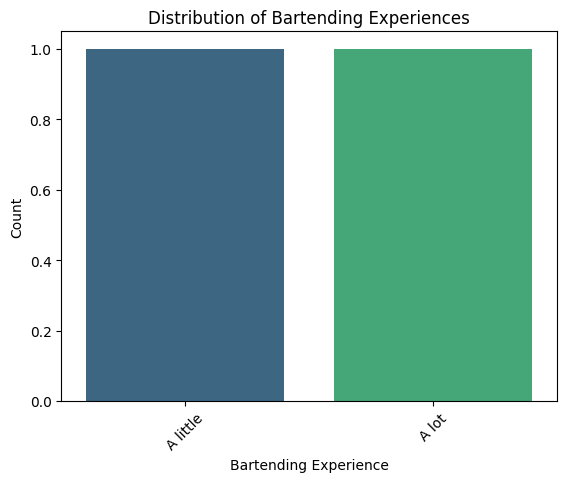

C:\Users\Christian\AppData\Local\Temp\ipykernel_8336\4136888342.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=pre_df, x="VR", palette="viridis")


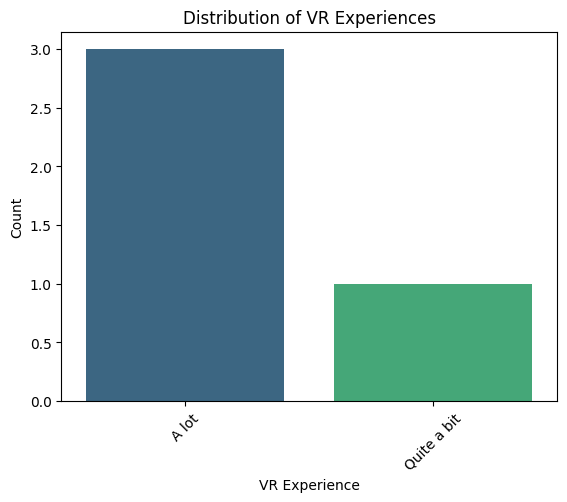

C:\Users\Christian\AppData\Local\Temp\ipykernel_8336\4136888342.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=pre_df, x="What is your age?", palette="viridis")


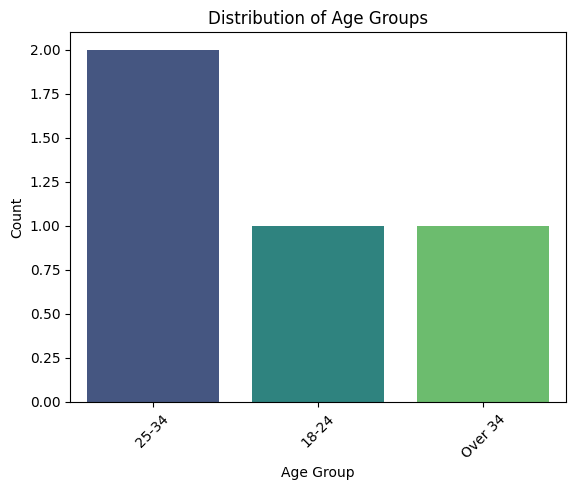

,mean,std,max,min
ID,2.5,1.290994,4.0,1.0
Starttidspunkt,2025-05-14 10:34:31,NaN,2025-05-14 10:51:16,2025-05-14 10:19:26
Færdiggørelsestidspunkt,2025-05-14 10:37:08.750000128,NaN,2025-05-14 10:52:19,2025-05-14 10:26:27
Navn,NaN,NaN,NaN,NaN
Senest ændret tidspunkt,NaN,NaN,NaN,NaN
Your test Number (Get your test conductor to fill this out),2.5,1.290994,4.0,1.0


In [7]:
sns.countplot(data=pre_df, x="Bartending", palette="viridis")
plt.title("Distribution of Bartending Experiences")
plt.xlabel("Bartending Experience")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

sns.countplot(data=pre_df, x="VR", palette="viridis")
plt.title("Distribution of VR Experiences")
plt.xlabel("VR Experience")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()
sns.countplot(data=pre_df, x="What is your age?", palette="viridis")
plt.title("Distribution of Age Groups")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

pre_summerize = pd.DataFrame({
    'mean': pre_df.describe().loc['mean'],
    'std': pre_df.describe().loc['std'],
    'max': pre_df.describe().loc['max'],
    'min': pre_df.describe().loc['min']
})
pre_summerize

# Post questioner  

## Nasa-TLX

In [8]:
# uses the pertable https://www.tandfonline.com/doi/full/10.1080/00140139.2021.1876927?scroll=top&needAccess=true
def interpret_tlx_quartile(score):
    if score < quartiles[0.25]:
        return "Very Low"
    elif score < quartiles[0.5]:
        return "Low"
    elif score < quartiles[0.75]:
        return "High"
    else:
        return "Very High"

last_6_columns = post_pf.iloc[:, -6:].copy()
last_6_columns.columns = [
    "Mental Demand",
    "Physical Demand",
    "Temporal Demand",
    "Performance",
    "Effort",
    "Frustration Level"
]

last_6_columns = last_6_columns.applymap(lambda x: min(x, 20) if pd.notna(x) else x)
TLX_allScore = last_6_columns.applymap(lambda x: x * 5 if pd.notna(x) else x)

TLX_allScore["ID"] = post_pf.iloc[:, 6]
TLX_allScore["TLX Score"] = TLX_allScore[[
    "Mental Demand", "Physical Demand", "Temporal Demand",
    "Performance", "Effort", "Frustration Level"
]].mean(axis=1)
# Calculate quartiles for TLX Score
quartiles = TLX_allScore["TLX Score"].quantile([0.25, 0.5, 0.75]).to_dict()

# Add interpretation for each participant
TLX_allScore["Interpretation"] = TLX_allScore["TLX Score"].apply(interpret_tlx_quartile)

# Calculate and print average TLX Score and its interpretation
mean_tlx = TLX_allScore["TLX Score"].mean()
mean_interpretation = interpret_tlx_quartile(mean_tlx)
print(f"Mean TLX Score: {mean_tlx:.2f} ({mean_interpretation})")
omega_value = calculate_omega(TLX_allScore[[
    "Mental Demand", "Physical Demand", "Temporal Demand",
    "Performance", "Effort", "Frustration Level"
]])

print(f"The reliability of the Nasa-TLX was {interpret_omega(omega_value)}, with a McDonald's Omega (TLX combined) = {omega_value:.3f}")

TLX_allScore

C:\Users\Christian\AppData\Local\Temp\ipykernel_8336\2060517454.py:22: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  last_6_columns = last_6_columns.applymap(lambda x: min(x, 20) if pd.notna(x) else x)
C:\Users\Christian\AppData\Local\Temp\ipykernel_8336\2060517454.py:23: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  TLX_allScore = last_6_columns.applymap(lambda x: x * 5 if pd.notna(x) else x)


Mean TLX Score: 34.38 (Low)
The reliability of the Nasa-TLX was Unacceptable, with a McDonald's Omega (TLX combined) = 0.000


,Mental Demand,Physical Demand,Temporal Demand,Performance,Effort,Frustration Level,ID,TLX Score,Interpretation
0,25,15,35,75,60,10,1,36.666667,Low
1,75,5,50,25,25,50,4,38.333333,High
2,25,40,20,65,40,70,2,43.333333,Very High
3,15,20,25,10,20,25,3,19.166667,Very Low


## IEQ

In [9]:
questions_df = post_pf.iloc[:, 18:49].copy()
questions_df = questions_df.apply(pd.to_numeric, errors='coerce')

questions_to_reverse_indices = [5, 7, 9, 17, 19]
for index in questions_to_reverse_indices:
    column_name = questions_df.columns[index]
    questions_df[column_name] = 8 - questions_df[column_name]

IEQ_scores_list = questions_df.sum(axis=1, skipna=True)
IEQ_scores = pd.DataFrame({
    "IEQ Score": IEQ_scores_list,
    "Participant Number": post_pf.iloc[:, 6].values,
    "Single Question Measure of Immersion": post_pf.iloc[:, 39].values
})

def interpret_ieq(score):
    if score >= 180:
        return "Top"
    elif score >= 124:
        return "Middle"
    else:
        return "Bottom"

IEQ_scores["Interpretation"] = IEQ_scores["IEQ Score"].apply(interpret_ieq)
print(f"Mean IEQ Score: {IEQ_scores['IEQ Score'].mean()} ({interpret_ieq(IEQ_scores['IEQ Score'].mean())})")

IEQ_scores

Mean IEQ Score: 154.5 (Middle)


,IEQ Score,Participant Number,Single Question Measure of Immersion,Interpretation
0,162,1,6,Middle
1,185,4,2,Top
2,141,2,5,Middle
3,130,3,2,Middle


## SUS

In [10]:
def calc_sus(row):

    scores = []
    even = 0
    odd = 0
    for i, ans in enumerate(row):
        result = 0
        try:
            result = float(ans)
        except:
            result = np.nan
        
        if (i % 2) == 0: 
            odd += result
        else:  # even
            even += result
    sus_score = 2.5*(20 + odd - even)
    return sus_score

#follow table 8 in: https://www.tandfonline.com/doi/full/10.1080/10447310802205776#d1e2060
def interpret_sus(sus_score):
    if sus_score >= 100:
        return "Best imaginable"
    elif sus_score >= 85.58:
        return "Excellent"
    elif sus_score >= 72.75:
        return "Good"
    elif sus_score >= 52.01:
        return "OK"
    elif sus_score >= 39.17:
        return "Poor"
    elif sus_score >= 25.00:
        return "Worst imaginable"
    else:
        return "Awful"


sus_columns = post_pf.columns[8:18]
sus_answers = post_pf[sus_columns]


sus_scores = sus_answers.apply(calc_sus, axis=1)

sus_df = pd.DataFrame(post_pf, columns=['Participant Number (Test conductor fills out)'])
sus_df = sus_df.rename(columns={'Participant Number (Test conductor fills out)': 'ID'})
sus_df['SUS'] = sus_scores
sus_df['Interpretation'] = sus_df['SUS'].apply(interpret_sus)
print(f"mean sus: {sus_df['SUS'].mean()} ± {sus_df['SUS'].std()} , n = {len(sus_df)}, min = {sus_df['SUS'].min()}, max = {sus_df['SUS'].max()} , sus interpretation: {interpret_sus(sus_df['SUS'].mean())}")

sus_df


mean sus: 66.25 ± 25.617376914898998 , n = 4, min = 40.0, max = 95.0 , sus interpretation: OK


,ID,SUS,Interpretation
0,1,95.0,Excellent
1,4,80.0,Good
2,2,40.0,Poor
3,3,50.0,Poor


# Performances 

Mean per participant:
                total_score  time_taken  total_pouring_deviation  \
participant_id                                                     
1                 33.595639   63.817124                83.211866   
2                 33.681397  101.999990                43.354833   
3                  0.000000  251.119900                39.394340   
4                 41.955220  104.779977                69.376317   

                wrong_ingredients  
participant_id                     
1                        0.857143  
2                        0.333333  
3                        1.000000  
4                        1.000000  


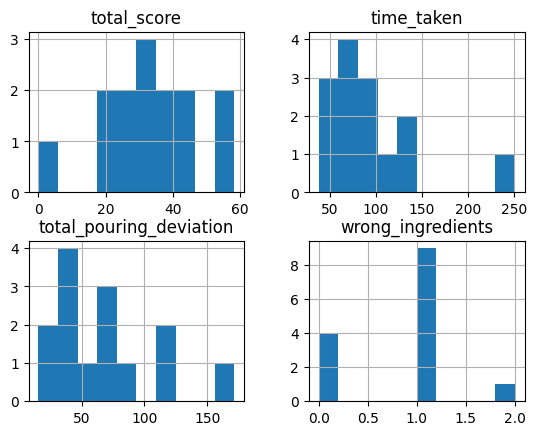

Correlation matrix:
                         participant_id  total_score  time_taken  \
participant_id                 1.000000     0.068824    0.508656   
total_score                    0.068824     1.000000   -0.471267   
time_taken                     0.508656    -0.471267    1.000000   
total_pouring_deviation       -0.180881     0.064236   -0.354424   
wrong_ingredients              0.107123    -0.230194   -0.038382   

                         total_pouring_deviation  wrong_ingredients  
participant_id                         -0.180881           0.107123  
total_score                             0.064236          -0.230194  
time_taken                             -0.354424          -0.038382  
total_pouring_deviation                 1.000000           0.587911  
wrong_ingredients                       0.587911           1.000000  


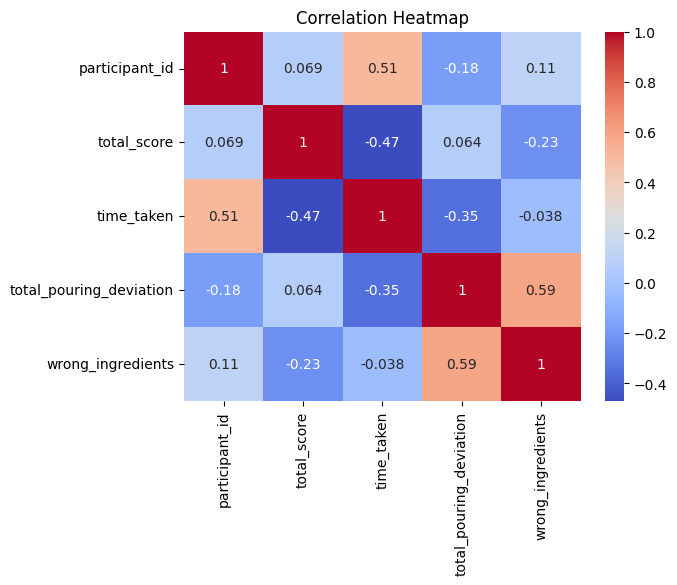

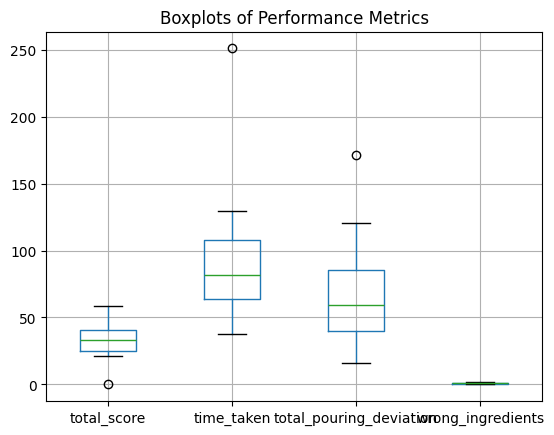

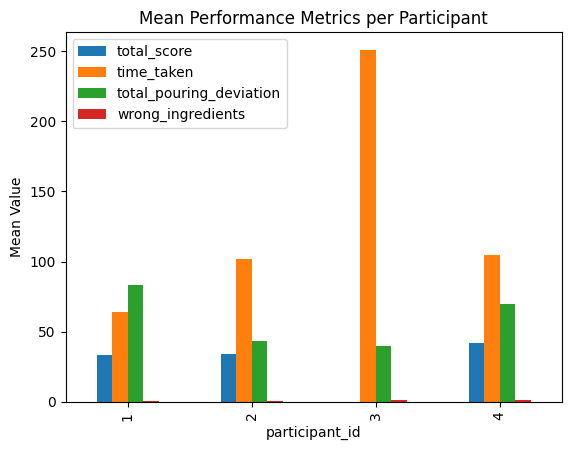

In [11]:
print("Mean per participant:")
print(performance_df.groupby('participant_id').mean())

performance_df.hist(column=['total_score', 'time_taken', 'total_pouring_deviation', 'wrong_ingredients'])
plt.show()

print("Correlation matrix:")
print(performance_df.corr())

corr = performance_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

performance_df.boxplot(column=['total_score', 'time_taken', 'total_pouring_deviation', 'wrong_ingredients'])
plt.title("Boxplots of Performance Metrics")
plt.show()

performance_df.groupby('participant_id').mean()[['total_score', 'time_taken', 'total_pouring_deviation', 'wrong_ingredients']].plot(kind='bar')
plt.title("Mean Performance Metrics per Participant")
plt.ylabel("Mean Value")
plt.show()

Stuff to do:

compare score with sus

sus with tlx 

IEQ with sus

IEQ with tlx

Correlation between mean performance score and SUS:
             total_score       SUS
total_score     1.000000  0.460189
SUS             0.460189  1.000000


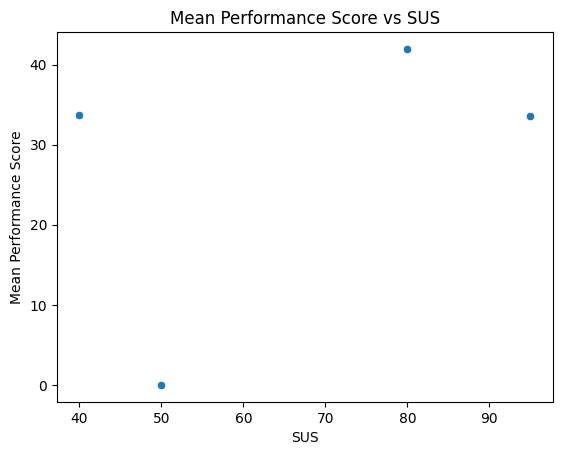

Correlation between SUS and TLX Score:
                SUS  TLX Score
SUS        1.000000   0.163517
TLX Score  0.163517   1.000000


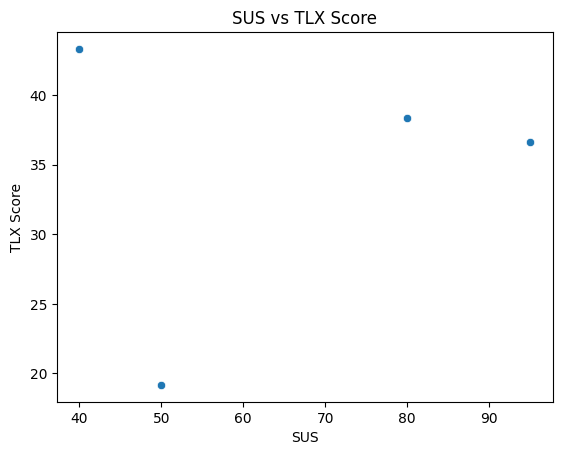

Correlation between IEQ Score and SUS:
           IEQ Score       SUS
IEQ Score   1.000000  0.743488
SUS         0.743488  1.000000


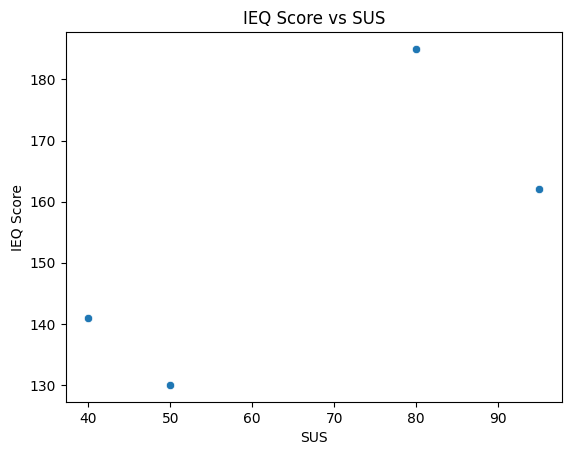

Correlation between IEQ Score and TLX Score:
           IEQ Score  TLX Score
IEQ Score      1.000      0.508
TLX Score      0.508      1.000


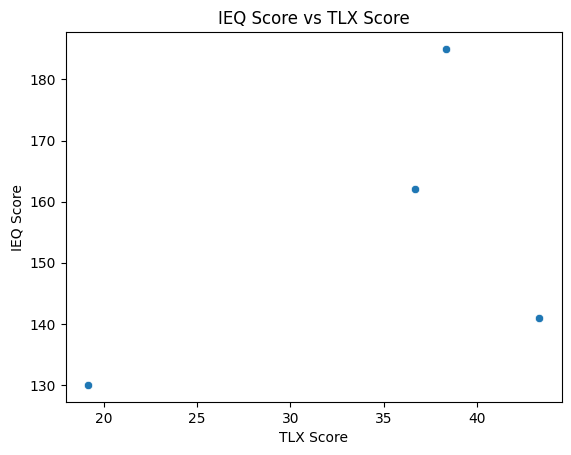

Full correlation matrix (IEQ, SUS, TLX, Performance):
                        IEQ Score       SUS  TLX Score  Mean Performance Score
IEQ Score                1.000000  0.743488   0.508000                0.793794
SUS                      0.743488  1.000000   0.163517                0.460189
TLX Score                0.508000  0.163517   1.000000                0.926302
Mean Performance Score   0.793794  0.460189   0.926302                1.000000


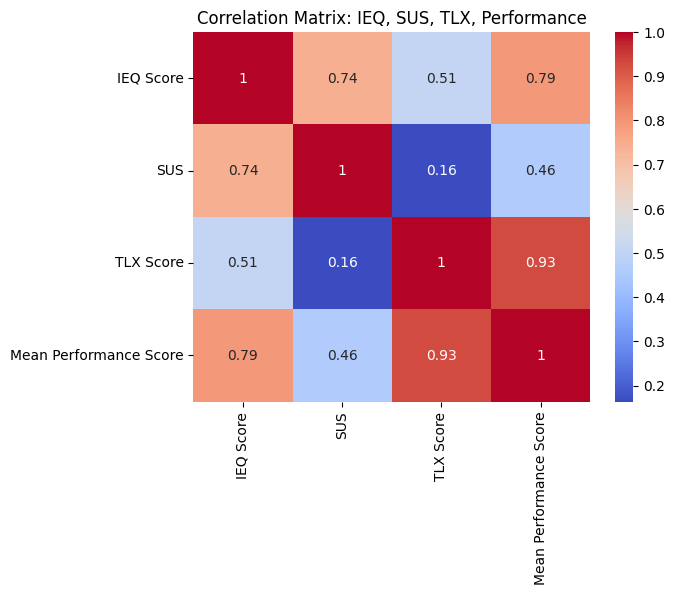

In [12]:
# Merge dataframes on participant ID/number for pairwise comparisons
# 1. Compare performance score with SUS
perf_mean = performance_df.groupby('participant_id')['total_score'].mean().reset_index()
perf_sus = pd.merge(perf_mean, sus_df, left_on='participant_id', right_on='ID')

print("Correlation between mean performance score and SUS:")
print(perf_sus[['total_score', 'SUS']].corr())

sns.scatterplot(data=perf_sus, x='SUS', y='total_score')
plt.title('Mean Performance Score vs SUS')
plt.xlabel('SUS')
plt.ylabel('Mean Performance Score')
plt.show()

# 2. SUS with TLX
sus_tlx = pd.merge(sus_df, TLX_allScore, left_on='ID', right_on='ID')
print("Correlation between SUS and TLX Score:")
print(sus_tlx[['SUS', 'TLX Score']].corr())

sns.scatterplot(data=sus_tlx, x='SUS', y='TLX Score')
plt.title('SUS vs TLX Score')
plt.xlabel('SUS')
plt.ylabel('TLX Score')
plt.show()

# 3. IEQ with SUS
ieq_sus = pd.merge(IEQ_scores, sus_df, left_on='Participant Number', right_on='ID')
print("Correlation between IEQ Score and SUS:")
print(ieq_sus[['IEQ Score', 'SUS']].corr())

sns.scatterplot(data=ieq_sus, x='SUS', y='IEQ Score')
plt.title('IEQ Score vs SUS')
plt.xlabel('SUS')
plt.ylabel('IEQ Score')
plt.show()

# 4. IEQ with TLX
ieq_tlx = pd.merge(IEQ_scores, TLX_allScore, left_on='Participant Number', right_on='ID')
print("Correlation between IEQ Score and TLX Score:")
print(ieq_tlx[['IEQ Score', 'TLX Score']].corr())

sns.scatterplot(data=ieq_tlx, x='TLX Score', y='IEQ Score')
plt.title('IEQ Score vs TLX Score')
plt.xlabel('TLX Score')
plt.ylabel('IEQ Score')
plt.show()

# Combine all relevant scores into a single dataframe for a full correlation matrix
combined_df = pd.DataFrame({
    'Participant Number': IEQ_scores['Participant Number'],
    'IEQ Score': IEQ_scores['IEQ Score'],
    'SUS': sus_df.set_index('ID').loc[IEQ_scores['Participant Number']]['SUS'].values,
    'TLX Score': TLX_allScore.set_index('ID').loc[IEQ_scores['Participant Number']]['TLX Score'].values,
    'Mean Performance Score': perf_mean.set_index('participant_id').loc[IEQ_scores['Participant Number']]['total_score'].values
})

corr_matrix = combined_df.drop(columns=['Participant Number']).corr()
print("Full correlation matrix (IEQ, SUS, TLX, Performance):")
print(corr_matrix)

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix: IEQ, SUS, TLX, Performance")
plt.show()

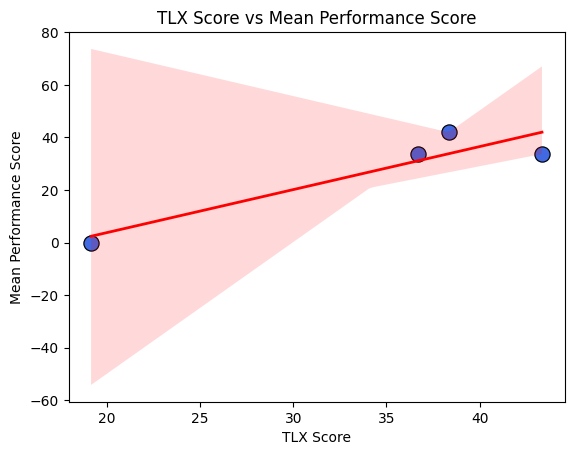

Correlation between TLX Score and Mean Performance Score: 0.926


In [13]:
sns.scatterplot(data=combined_df, x='TLX Score', y='Mean Performance Score', s=120, color='royalblue', edgecolor='black')
sns.regplot(data=combined_df, x='TLX Score', y='Mean Performance Score', scatter=False, color='red', line_kws={'linewidth':2})
plt.title('TLX Score vs Mean Performance Score')
plt.xlabel('TLX Score')
plt.ylabel('Mean Performance Score')
plt.show()

# Show the correlation coefficient
corr_value = combined_df['TLX Score'].corr(combined_df['Mean Performance Score'])
print(f"Correlation between TLX Score and Mean Performance Score: {corr_value:.3f}")

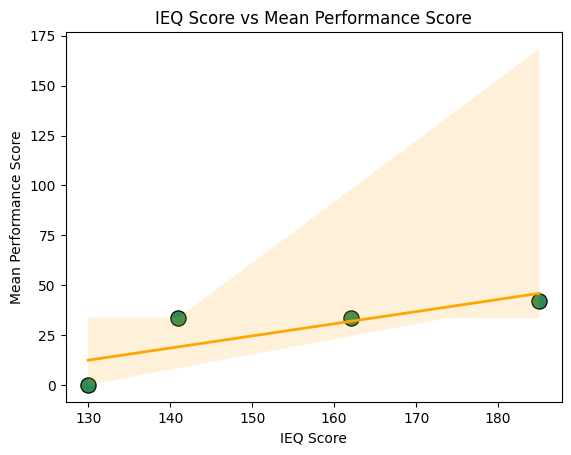

Correlation between IEQ Score and Mean Performance Score: 0.794


In [14]:
sns.scatterplot(data=combined_df, x='IEQ Score', y='Mean Performance Score', s=120, color='seagreen', edgecolor='black')
sns.regplot(data=combined_df, x='IEQ Score', y='Mean Performance Score', scatter=False, color='orange', line_kws={'linewidth':2})
plt.title('IEQ Score vs Mean Performance Score')
plt.xlabel('IEQ Score')
plt.ylabel('Mean Performance Score')
plt.show()

corr_value_ieq = combined_df['IEQ Score'].corr(combined_df['Mean Performance Score'])
print(f"Correlation between IEQ Score and Mean Performance Score: {corr_value_ieq:.3f}")


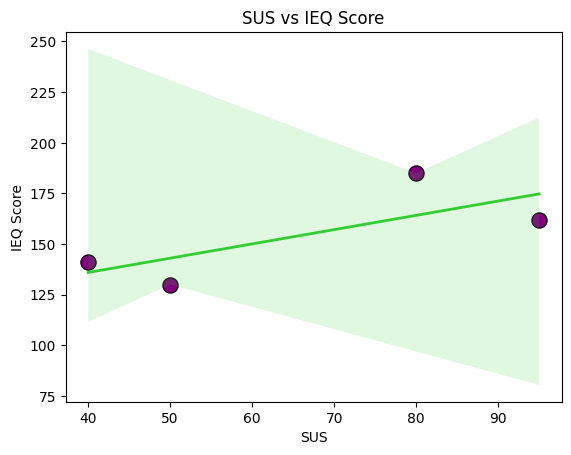

Correlation between SUS and IEQ Score: 0.743


In [15]:
sns.scatterplot(data=combined_df, x='SUS', y='IEQ Score', s=120, color='purple', edgecolor='black')
sns.regplot(data=combined_df, x='SUS', y='IEQ Score', scatter=False, color='limegreen', line_kws={'linewidth':2})
plt.title('SUS vs IEQ Score')
plt.xlabel('SUS')
plt.ylabel('IEQ Score')
plt.show()

corr_value_sus_ieq = combined_df['SUS'].corr(combined_df['IEQ Score'])
print(f"Correlation between SUS and IEQ Score: {corr_value_sus_ieq:.3f}")

Intercept: -78.35229873636118
Coefficients: [ 0.77448818 -0.2112915 ]
R^2: 0.6678893392689058


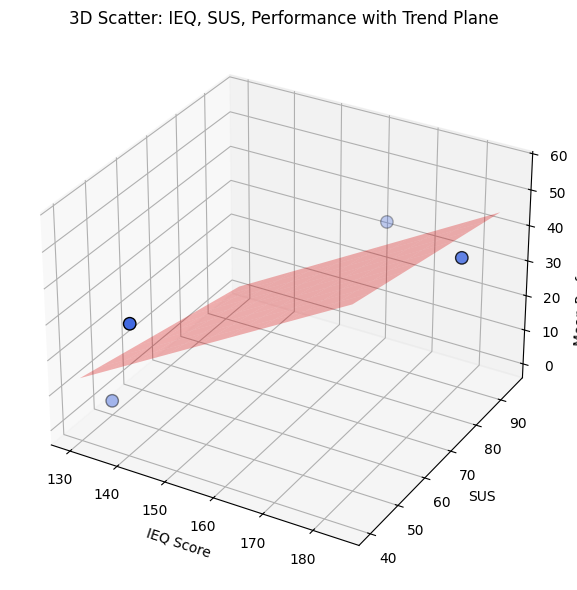

In [19]:
from mpl_toolkits.mplot3d import Axes3D
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score


fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Extract variables
x = combined_df['IEQ Score']
y = combined_df['SUS']
z = combined_df['Mean Performance Score']

# Scatter plot
ax.scatter(x, y, z, color='royalblue', s=80, edgecolor='k')

# Fit plane (trendline)
X = np.column_stack((x, y))
model = LinearRegression().fit(X, z)
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)
z_pred = model.predict(X)
print("R^2:", r2_score(z, z_pred))
xx, yy = np.meshgrid(np.linspace(x.min(), x.max(), 10),
                     np.linspace(y.min(), y.max(), 10))
zz = model.intercept_ + model.coef_[0]*xx + model.coef_[1]*yy
ax.plot_surface(xx, yy, zz, alpha=0.3, color='red')

ax.set_xlabel('IEQ Score')
ax.set_ylabel('SUS')
ax.set_zlabel('Mean Performance Score')
ax.set_title('3D Scatter: IEQ, SUS, Performance with Trend Plane')
plt.tight_layout()
plt.show()

R^2 for TLX+SUS -> Performance plane: 0.956


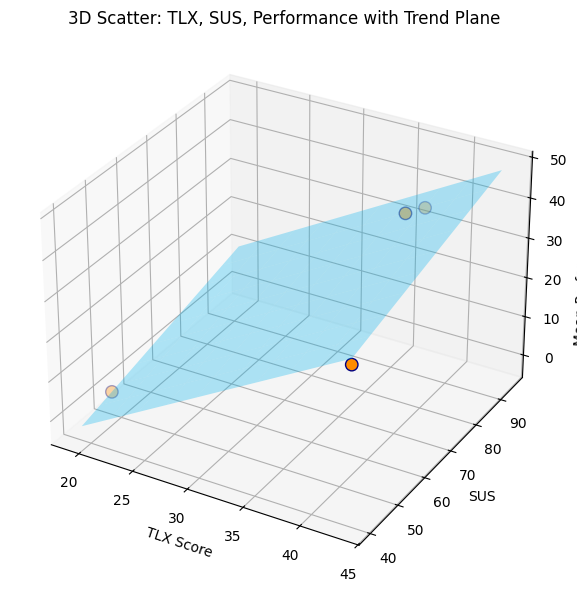

In [21]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Extract variables
x_tlx = combined_df['TLX Score']
y_sus = combined_df['SUS']
z_perf = combined_df['Mean Performance Score']

# Scatter plot with new colors
ax.scatter(x_tlx, y_sus, z_perf, color='darkorange', s=80, edgecolor='navy')

# Fit plane (trendline)
r2_plane = r2_score(z_perf, z_pred_plane)
print(f"R^2 for TLX+SUS -> Performance plane: {r2_plane:.3f}")
X_plane = np.column_stack((x_tlx, y_sus))
model_plane = LinearRegression().fit(X_plane, z_perf)
z_pred_plane = model_plane.predict(X_plane)
xx_tlx, yy_sus = np.meshgrid(
    np.linspace(x_tlx.min(), x_tlx.max(), 10),
    np.linspace(y_sus.min(), y_sus.max(), 10)
)
zz_perf = model_plane.intercept_ + model_plane.coef_[0]*xx_tlx + model_plane.coef_[1]*yy_sus
ax.plot_surface(xx_tlx, yy_sus, zz_perf, alpha=0.3, color='deepskyblue')

ax.set_xlabel('TLX Score')
ax.set_ylabel('SUS')
ax.set_zlabel('Mean Performance Score')
ax.set_title('3D Scatter: TLX, SUS, Performance with Trend Plane')
plt.tight_layout()
plt.show()